## Installing Required Librareis


In [ ]:
! pip install pandas
! pip install scikit-learn
! pip install matplotlib
! pip install seaborn
! pip install numpy   
! pip install openpyxl
! pip install xgboost
! pip install plotly    

In [ ]:
## Importing Required Libraries for Data Analysis

: 

In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
## Loading and Extracting Data from Excel into DataFrame

In [2]:


# Load the Excel file (update the filename if needed)
df = pd.read_excel("C:/Users/hp/Documents/Netmore Task/data/Raw Data set.xlsx")

# Create the 'IsAtRisk' column based on the DSR_percent
# If DSR_percent is less than 85, 'IsAtRisk' will be 1 (True), otherwise it will be 0 (False).
df['IsAtRisk'] = (df['DSR_percent'] < 85).astype(int)

display(df.head())


,MeterID,Latitude,Longitude,LidType,RSSI_dBm,SNR_dB,SpreadingFactor,ExpectedReads,ActualReads,DSR_percent,Depth_mm,DistanceToNearestGateway (meters),IsAtRisk
0,MTR100017,53.724756,-1.677932,Composite,-84.9,10.9,11,24,24,100.0,450,147,0
1,MTR100064,53.480935,-1.262868,Plastic,-84.2,11.6,9,24,24,100.0,450,95,0
2,MTR100143,53.500878,-1.233653,Composite,-81.9,12.8,8,24,24,100.0,450,63,0
3,MTR100151,53.439562,-1.798205,Plastic,-83.5,14.5,8,24,24,100.0,400,78,0
4,MTR100159,53.928216,-1.774210,Plastic,-82.4,9.0,9,24,24,100.0,800,76,0


In [14]:
df.columns.tolist()


['MeterID',
 'Latitude',
 'Longitude',
 'LidType',
 'RSSI_dBm',
 'SNR_dB',
 'SpreadingFactor',
 'ExpectedReads',
 'ActualReads',
 'DSR_percent',
 'Depth_mm',
 'DistanceToNearestGateway_meters',
 'IsAtRisk']

Columns found in DataFrame: ['MeterID', 'Latitude', 'Longitude', 'LidType', 'RSSI_dBm', 'SNR_dB', 'SpreadingFactor', 'ExpectedReads', 'ActualReads', 'DSR_percent', 'Depth_mm', 'DistanceToNearestGateway_meters', 'IsAtRisk']


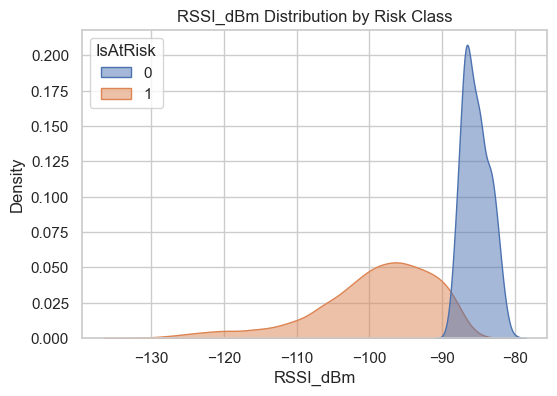

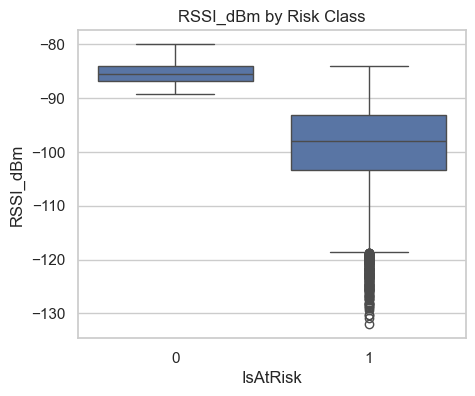

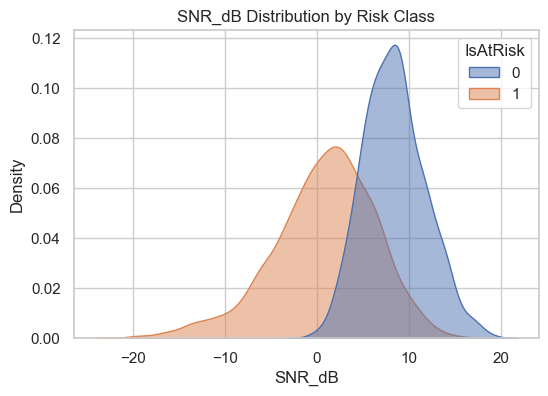

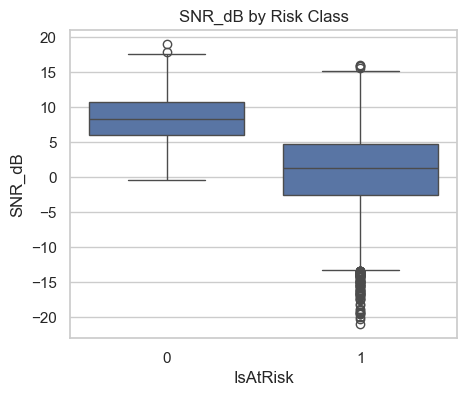

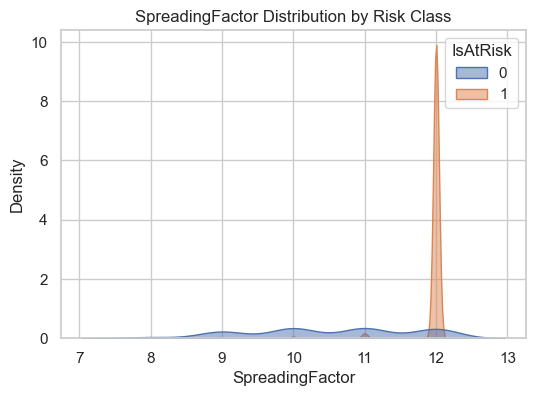

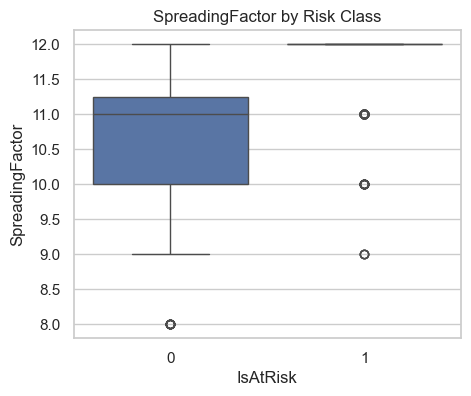

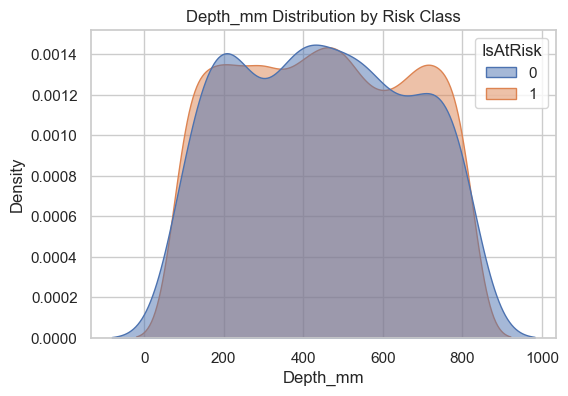

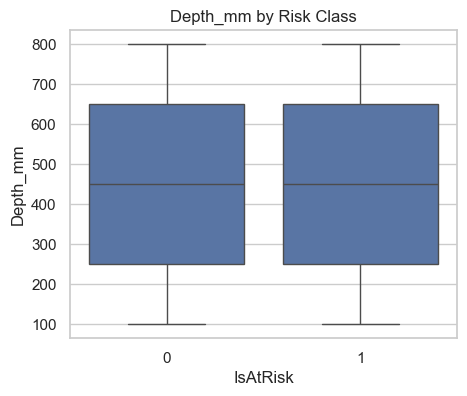

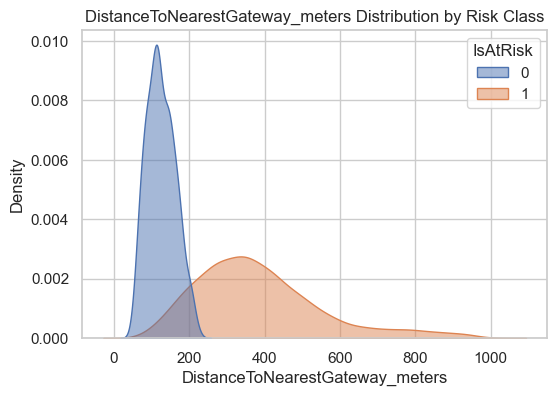

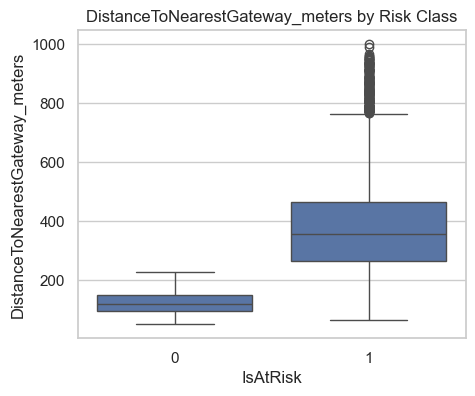


===== T-Test Results (Mean Difference) =====
RSSI_dBm: t-stat = 94.529, p = 0.000e+00
SNR_dB: t-stat = 46.384, p = 3.437e-252
SpreadingFactor: t-stat = -29.902, p = 2.056e-118
Depth_mm: t-stat = -0.138, p = 8.900e-01
DistanceToNearestGateway_meters: t-stat = -86.794, p = 0.000e+00

===== KS-Test Results (Distribution Difference) =====
RSSI_dBm: KS-stat = 0.941, p = 1.630e-322
SNR_dB: KS-stat = 0.630, p = 6.460e-189
SpreadingFactor: KS-stat = 0.728, p = 3.919e-263
Depth_mm: KS-stat = 0.017, p = 9.986e-01
DistanceToNearestGateway_meters: KS-stat = 0.862, p = 7.213e-322

===== Class Balance =====
IsAtRisk
1    88.8
0    11.2
Name: proportion, dtype: float64


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ks_2samp

# ✅ Clean up any stray characters or spaces in column names
df.columns = df.columns.str.strip().str.replace('\n', '').str.replace('\r', '')

# ✅ Define correct feature list
features = [
    'RSSI_dBm',
    'SNR_dB',
    'SpreadingFactor',
    'Depth_mm',
    'DistanceToNearestGateway_meters'
]

# ✅ Check that all required columns exist
print("Columns found in DataFrame:", df.columns.tolist())

# ========================
# 📊 Visual Distribution
# ========================
for f in features:
    if f not in df.columns:
        print(f"⚠️ Skipping '{f}' — not found in dataframe columns.")
        continue
    
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=f, hue='IsAtRisk', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{f} Distribution by Risk Class')
    plt.xlabel(f)
    plt.ylabel('Density')
    plt.show()

    plt.figure(figsize=(5,4))
    sns.boxplot(data=df, x='IsAtRisk', y=f)
    plt.title(f'{f} by Risk Class')
    plt.show()

# ========================
# 📈 Statistical Tests
# ========================
print("\n===== T-Test Results (Mean Difference) =====")
for f in features:
    if f in df.columns:
        group0 = df[df['IsAtRisk']==0][f]
        group1 = df[df['IsAtRisk']==1][f]
        t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
        print(f"{f}: t-stat = {t_stat:.3f}, p = {p_val:.3e}")
    else:
        print(f"⚠️ {f} not found.")

print("\n===== KS-Test Results (Distribution Difference) =====")
for f in features:
    if f in df.columns:
        group0 = df[df['IsAtRisk']==0][f]
        group1 = df[df['IsAtRisk']==1][f]
        ks_stat, p_val = ks_2samp(group0, group1)
        print(f"{f}: KS-stat = {ks_stat:.3f}, p = {p_val:.3e}")
    else:
        print(f"⚠️ {f} not found.")

# ========================
# 🧮 Class Balance
# ========================
print("\n===== Class Balance =====")
print(df['IsAtRisk'].value_counts(normalize=True).mul(100).round(2))



===== Class Balance =====
IsAtRisk
1    88.8
0    11.2
Name: proportion, dtype: float64 



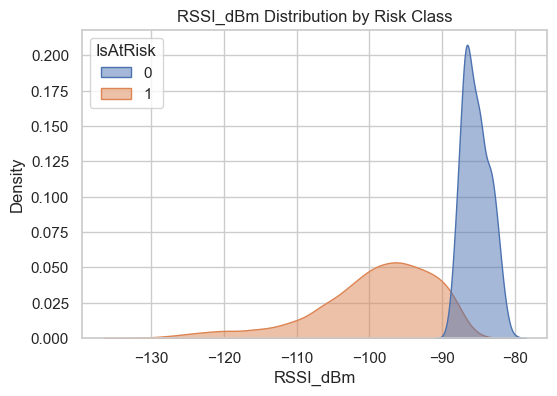

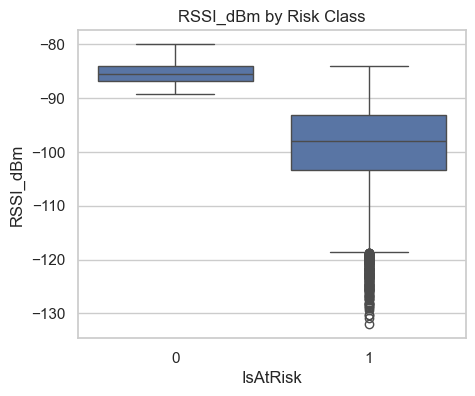

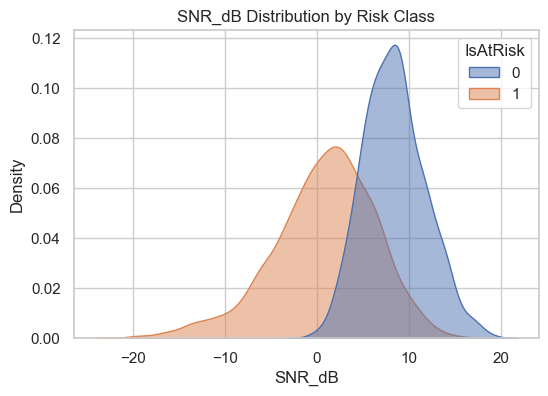

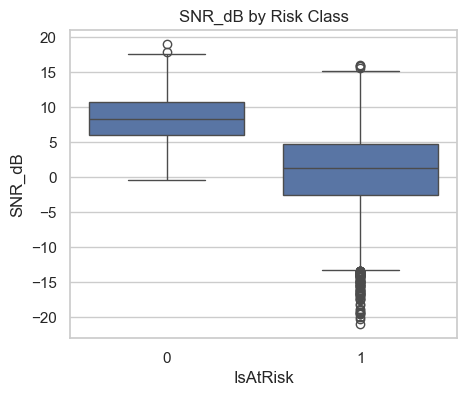

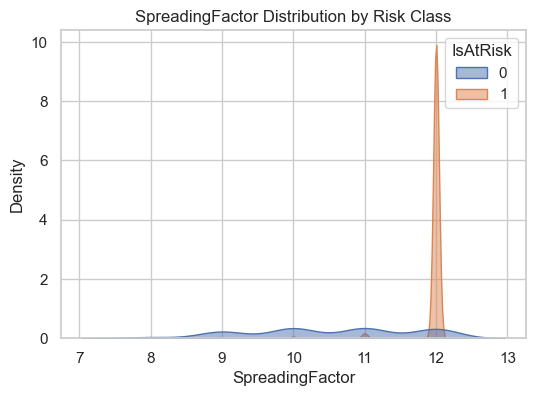

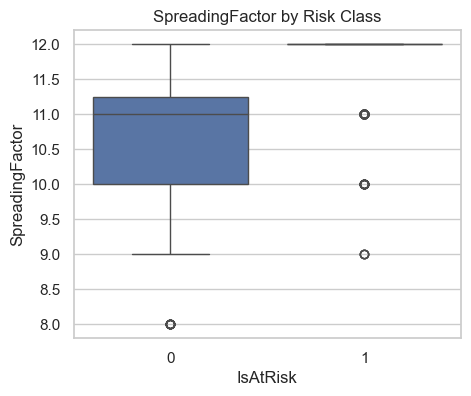

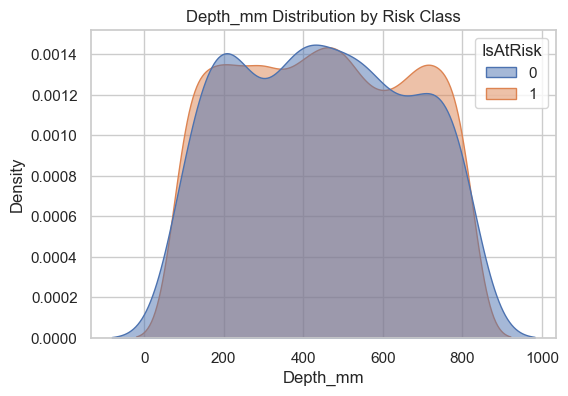

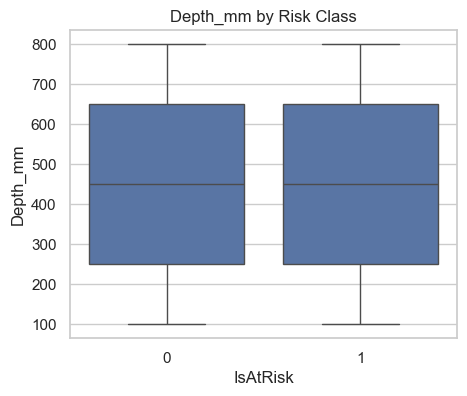

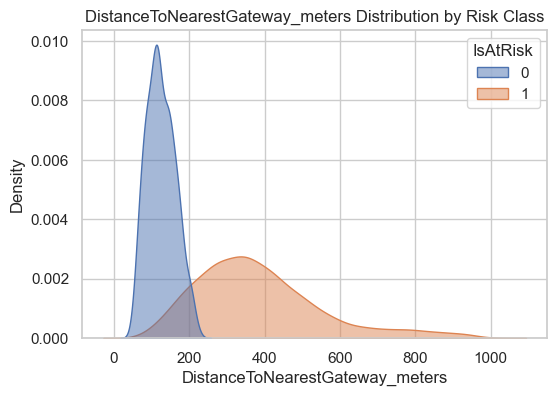

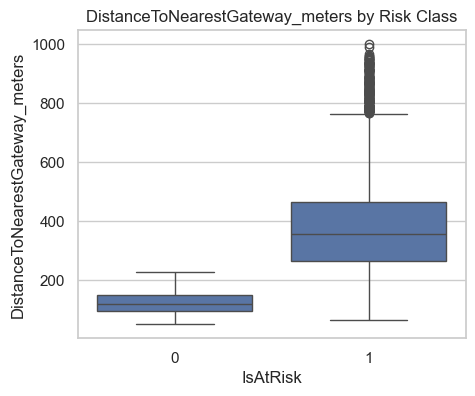


===== T-Test Results (Mean Difference) =====
RSSI_dBm: t-stat = 94.529, p = 0.000e+00
SNR_dB: t-stat = 46.384, p = 3.437e-252
SpreadingFactor: t-stat = -29.902, p = 2.056e-118
Depth_mm: t-stat = -0.138, p = 8.900e-01
DistanceToNearestGateway_meters: t-stat = -86.794, p = 0.000e+00

===== KS-Test Results (Distribution Difference) =====
RSSI_dBm: KS-stat = 0.941, p = 1.630e-322
SNR_dB: KS-stat = 0.630, p = 6.460e-189
SpreadingFactor: KS-stat = 0.728, p = 3.919e-263
Depth_mm: KS-stat = 0.017, p = 9.986e-01
DistanceToNearestGateway_meters: KS-stat = 0.862, p = 7.213e-322

===== LidType Distribution by Risk Class =====
IsAtRisk     0     1
LidType             
Cast Iron  107  1954
Composite  234  1277
Plastic    219  1209 



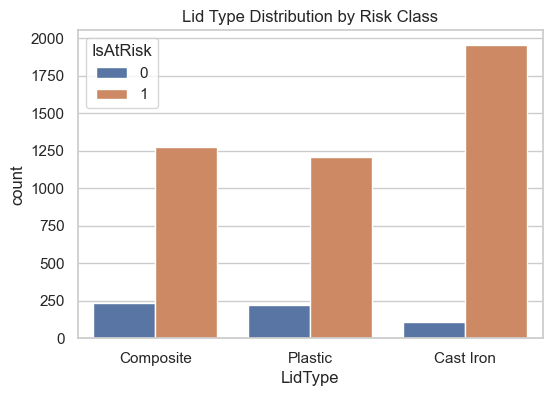

Chi-Square = 127.287, p = 2.291e-28


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ks_2samp, chi2_contingency

# Clean column names
df.columns = df.columns.str.strip().str.replace('\n', '').str.replace('\r', '')

# Ensure correct column names
df.rename(columns={'DistanceToNearestGateway (meters)': 'DistanceToNearestGateway_meters'}, inplace=True)

# ==========================================
# 1️⃣ NUMERICAL FEATURES vs TARGET (IsAtRisk)
# ==========================================

features = ['RSSI_dBm', 'SNR_dB', 'SpreadingFactor', 'Depth_mm', 'DistanceToNearestGateway_meters']

print("\n===== Class Balance =====")
print(df['IsAtRisk'].value_counts(normalize=True).mul(100).round(2), "\n")

# --- KDE and Boxplots
for f in features:
    if f not in df.columns:
        print(f"⚠️ Skipping '{f}' — not found in dataframe columns.")
        continue
    
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=f, hue='IsAtRisk', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{f} Distribution by Risk Class')
    plt.xlabel(f)
    plt.ylabel('Density')
    plt.show()

    plt.figure(figsize=(5,4))
    sns.boxplot(data=df, x='IsAtRisk', y=f)
    plt.title(f'{f} by Risk Class')
    plt.show()

# --- Statistical Tests
print("\n===== T-Test Results (Mean Difference) =====")
for f in features:
    if f in df.columns:
        group0 = df[df['IsAtRisk']==0][f]
        group1 = df[df['IsAtRisk']==1][f]
        t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
        print(f"{f}: t-stat = {t_stat:.3f}, p = {p_val:.3e}")

print("\n===== KS-Test Results (Distribution Difference) =====")
for f in features:
    if f in df.columns:
        group0 = df[df['IsAtRisk']==0][f]
        group1 = df[df['IsAtRisk']==1][f]
        ks_stat, p_val = ks_2samp(group0, group1)
        print(f"{f}: KS-stat = {ks_stat:.3f}, p = {p_val:.3e}")

# ==========================================
# 2️⃣ LID TYPE vs TARGET (IsAtRisk)
# ==========================================

print("\n===== LidType Distribution by Risk Class =====")
cross_tab = pd.crosstab(df['LidType'], df['IsAtRisk'])
print(cross_tab, "\n")

# --- Visualize
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='LidType', hue='IsAtRisk')
plt.title('Lid Type Distribution by Risk Class')
plt.show()

# --- Chi-Square Test
chi2, p, dof, expected = chi2_contingency(cross_tab)
print(f"Chi-Square = {chi2:.3f}, p = {p:.3e}")


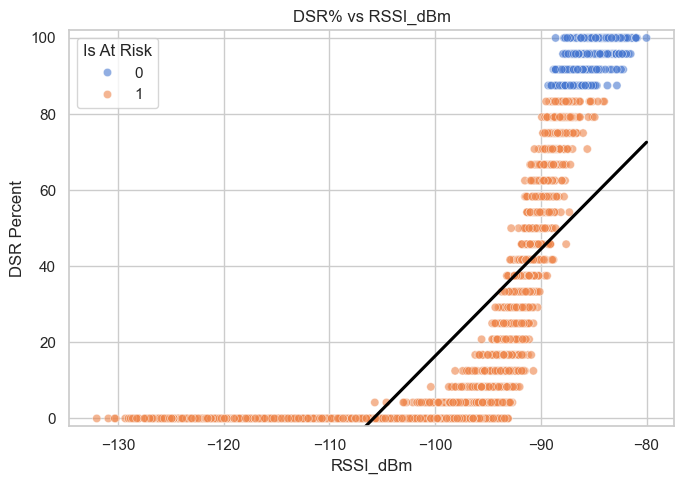

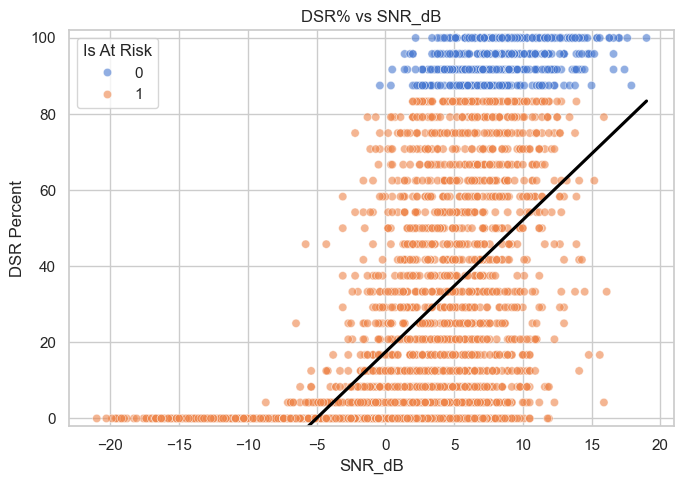

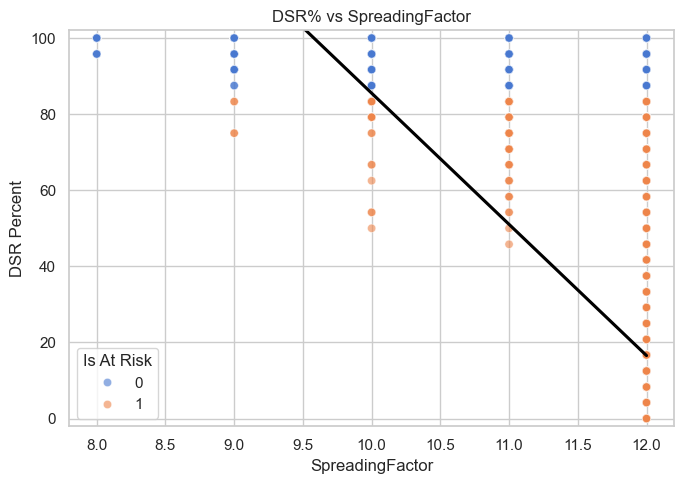

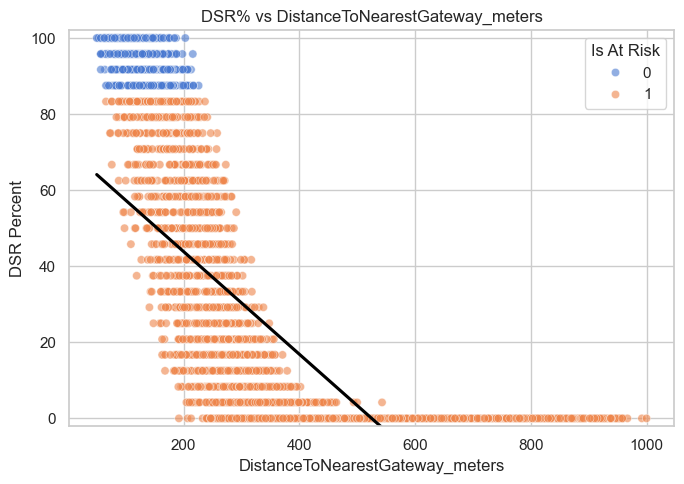

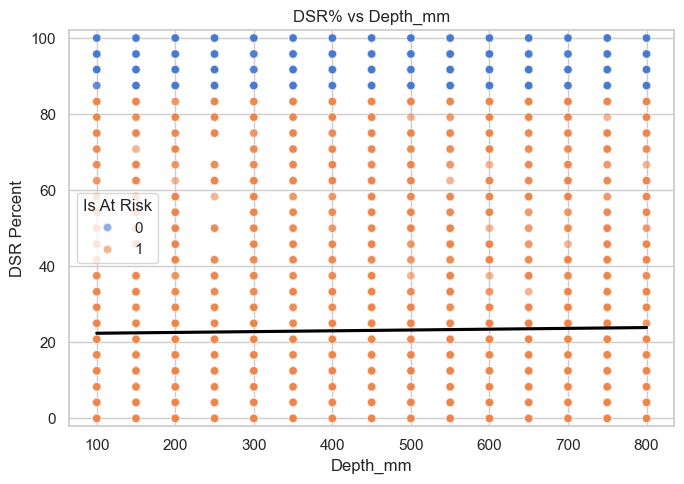

C:\Users\hp\AppData\Local\Temp\ipykernel_26224\3856550075.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='LidType', y='DSR_percent', palette='Set2')


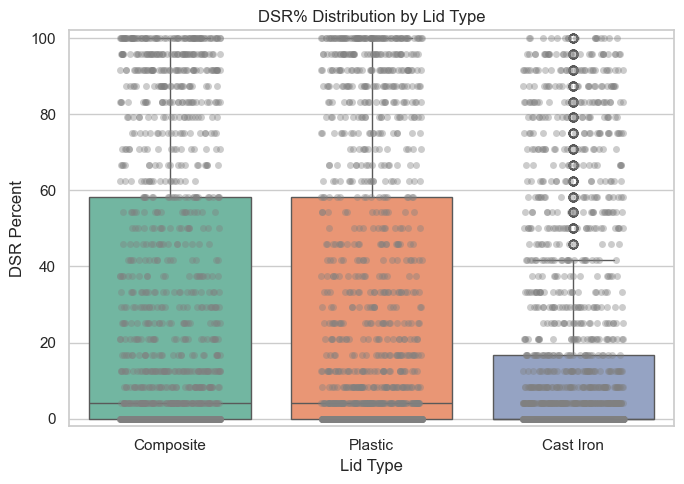

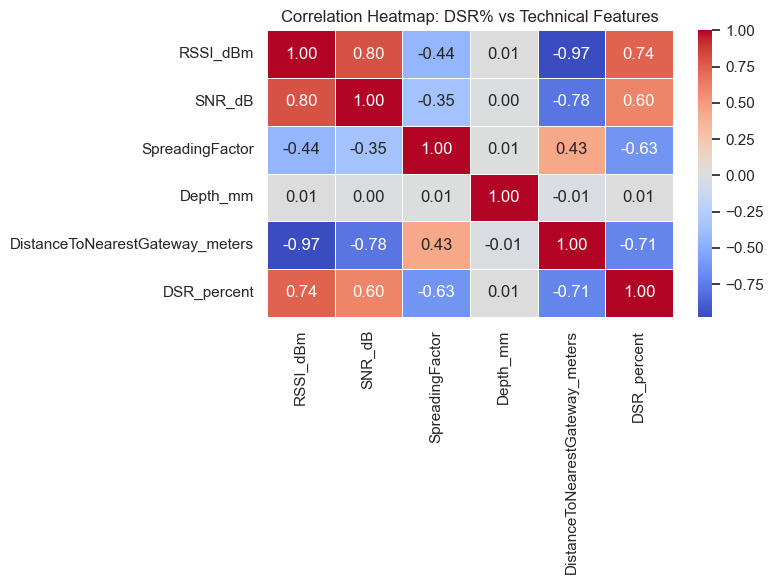

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", palette="muted")

# Define features to visualize
features = ['RSSI_dBm', 'SNR_dB', 'SpreadingFactor',
            'DistanceToNearestGateway_meters', 'Depth_mm']

# Automatically detect DSR range
y_min = np.floor(df['DSR_percent'].min() - 2)
y_max = np.ceil(df['DSR_percent'].max() + 2)

# 1️⃣ Continuous features vs DSR%
for f in features:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df, x=f, y='DSR_percent', hue='IsAtRisk', alpha=0.6)
    sns.regplot(data=df, x=f, y='DSR_percent', scatter=False, color='black', ci=None)
    plt.title(f'DSR% vs {f}')
    plt.xlabel(f)
    plt.ylabel('DSR Percent')
    plt.ylim(y_min, y_max)   # ensures all DSR values visible, even < 0 or >100
    plt.legend(title='Is At Risk', loc='best')
    plt.tight_layout()
    plt.show()

# 2️⃣ Categorical feature: LidType vs DSR%
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='LidType', y='DSR_percent', palette='Set2')
sns.stripplot(data=df, x='LidType', y='DSR_percent', color='gray', alpha=0.4, jitter=0.25)
plt.title('DSR% Distribution by Lid Type')
plt.xlabel('Lid Type')
plt.ylabel('DSR Percent')
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

# 3️⃣ Correlation Heatmap
corr_features = ['RSSI_dBm','SNR_dB','SpreadingFactor','Depth_mm',
                 'DistanceToNearestGateway_meters','DSR_percent']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: DSR% vs Technical Features')
plt.tight_layout()
plt.show()


In [3]:
# Create a new DataFrame to hold the info
info_df = pd.DataFrame(index=df.columns)
info_df['Non-Null Count'] = df.count().values
info_df['Dtype'] = df.dtypes.values

# Display the new DataFrame as a table
print("DataFrame Information Summary:")
display(info_df)

# You can also get the total memory usage separately
memory_usage_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"\nTotal Memory Usage: {memory_usage_mb:.2f} MB")

DataFrame Information Summary:


,Non-Null Count,Dtype
MeterID,5000,object
Latitude,5000,float64
Longitude,5000,float64
LidType,5000,object
RSSI_dBm,5000,float64
SNR_dB,5000,float64
SpreadingFactor,5000,int64
ExpectedReads,5000,int64
ActualReads,5000,int64
DSR_percent,5000,float64



Total Memory Usage: 1.05 MB


## Summarise the distribution of DSR across all meters.

--- Statistical Summary of DSR (%) ---
count    5000.000000
mean       23.121280
std        33.896733
min         0.000000
25%         0.000000
50%         4.200000
75%        41.700000
max       100.000000
Name: DSR_percent, dtype: float64


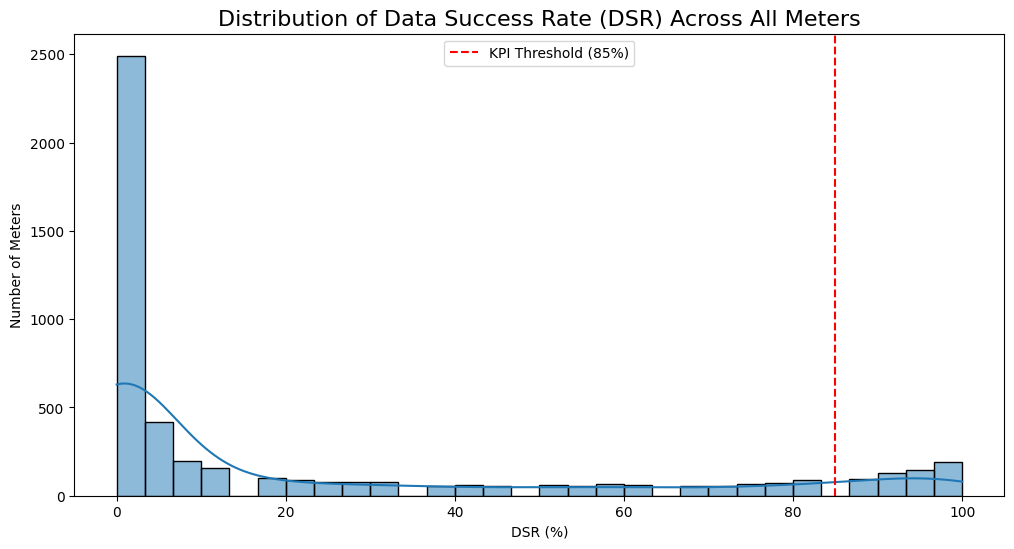

In [4]:
# --- Statistical Summary ---
print("--- Statistical Summary of DSR (%) ---")
# .describe() provides key stats like mean, median, std dev, etc.
print(df['DSR_percent'].describe())


plt.figure(figsize=(12, 6))
sns.histplot(df['DSR_percent'], kde=True, bins=30)
plt.title('Distribution of Data Success Rate (DSR) Across All Meters', fontsize=16)
plt.xlabel('DSR (%)')
plt.ylabel('Number of Meters')
plt.axvline(x=85, color='r', linestyle='--', label='KPI Threshold (85%)')
plt.legend()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_18984\3426387433.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




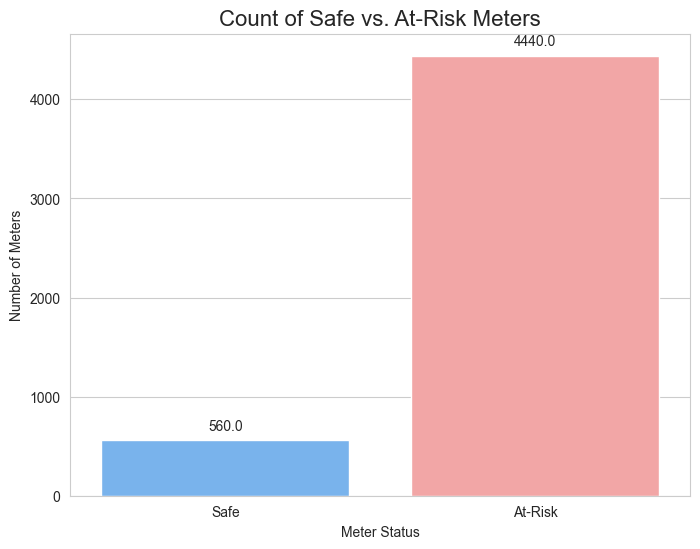

In [45]:
# Create the count plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='IsAtRisk', data=df, palette=['#66b3ff','#ff9999'])

# Add labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Count of Safe vs. At-Risk Meters', fontsize=16)
plt.xticks([0, 1], ['Safe', 'At-Risk']) # Label the x-axis ticks
plt.xlabel('Meter Status')
plt.ylabel('Number of Meters')
plt.show()


In [31]:
import plotly.express as px

# Create a scatter mapbox (not scatter_geo)
fig = px.scatter_mapbox(df,
                        lat='Latitude',
                        lon='Longitude',
                        color='DSR_percent',         # You can change this to 'RSSI_dBm', etc.
                        hover_name='MeterID',
                        hover_data=['RSSI_dBm', 'SNR_dB', 'LidType'],
                        zoom=7.1,
                        height=600)

# Use minimal map style and center over the UK
fig.update_layout(
    mapbox_style="carto-positron",      # Clean Mapbox style
    mapbox_center={"lat": 54, "lon": -2},  # Centered over UK
    margin={"r":0,"t":40,"l":0,"b":0},
    title="UK Meter Locations Colored by DSR Percent"
)

fig.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_18984\2633946290.py:4: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



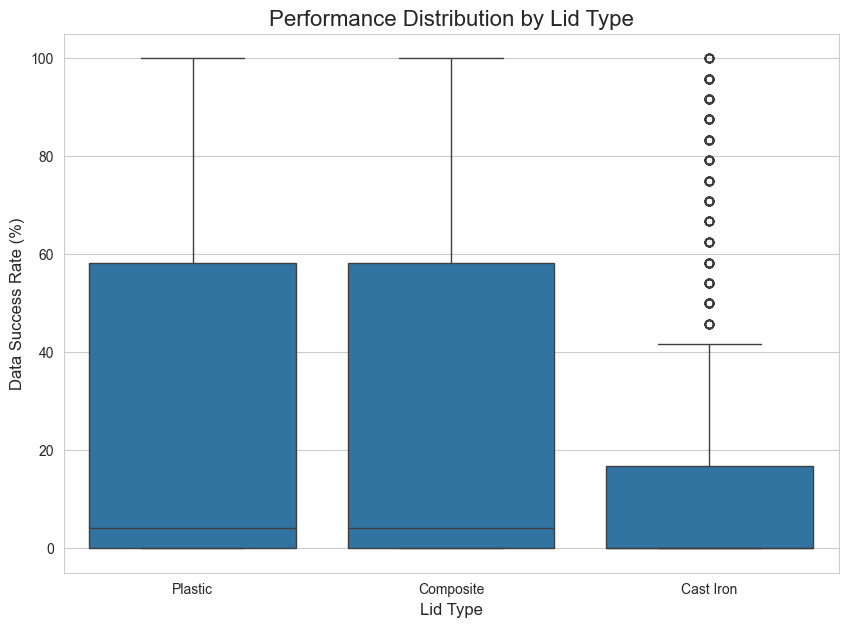

In [55]:
# Set a clean visual style for the plot
sns.set_style("whitegrid")

# Create the box plot
plt.figure(figsize=(10, 7))
sns.boxplot(data=df, 
            x='LidType', 
            y='DSR_percent',
            order=['Plastic', 'Composite', 'Cast Iron']) # Ensures a logical order on the x-axis

# Add a clear title and labels
plt.title('Performance Distribution by Lid Type', fontsize=16)
plt.xlabel('Lid Type', fontsize=12)
plt.ylabel('Data Success Rate (%)', fontsize=12)

# Display the plot
plt.show()